In [ ]:
print("\n----phase 1----")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
#load datasets
df=pd.read_csv(r"C:\Users\harin\OneDrive\Desktop\aiml task 1\dataset_synthetic.csv")
#load datas
print(df.head())
#check columns
print(df.columns)
#check datatypes
print(df.dtypes)
#check missing values
print(df.isnull().sum())
#remove duplicates
print(df.duplicated().sum())
df=df.drop_duplicates()
print(df)
#finding total startups
total_startups=len(df)
funded_startups=df[df["Funding_Success"]=="Yes"].shape[0]
#finding success percentage
success_percentage=(funded_startups/total_startups)*100
print("success_percentage",success_percentage)
print("Total startups",total_startups)


----phase 1----
   Startup_ID  Team_Size  Founder_Experience_Years  Startup_Age_Years  \
0           1          3                        15                  4   
1           2          4                        15                  5   
2           3         19                        11                  2   
3           4          4                        14                  3   
4           5          2                         7                  9   

     Industry       City  Funding_Goal  Funding_Raised Funding_Success  
0      EdTech     Mumbai        159050          875074             Yes  
1    AgriTech       Pune       1904038         1600511              No  
2      EdTech    Chennai        470005         2209947             Yes  
3  E-Commerce  Hyderabad       1596808         1114783              No  
4          AI       Pune       1538016          124867              No  
Index(['Startup_ID', 'Team_Size', 'Founder_Experience_Years',
       'Startup_Age_Years', 'Industry', 'Cit

In [ ]:
#phase 2
print("\n----phase 2----")
print("average team size:",df["Team_Size"].mean())
print("average founder experience",df["Founder_Experience_Years"].mean())
print("average startup age",df["Startup_Age_Years"].mean())

print("median team size",df["Team_Size"].median())
print("median founder experience",df["Founder_Experience_Years"].median() )
print("median startup age",df["Startup_Age_Years"].median())

print("std team size",df["Team_Size"].std())
print("std founder experience",df["Founder_Experience_Years"].std() )
print("std startup age",df["Startup_Age_Years"].std())

print(df[["Team_Size","Founder_Experience_Years","Startup_Age_Years"]].quantile([0.25,0.5,0.75]))
print(df[["Team_Size","Founder_Experience_Years","Startup_Age_Years"]].quantile(0.9))

#compare funded vs non funded
funded_df=df[df['Funding_Success']=="Yes"]
non_funded_df=df[df['Funding_Success']=="No"]

print("Average Team Size(Funded)",funded_df["Team_Size"].mean())
print("Average team size(non funded)",non_funded_df["Team_Size"].mean())

print("Average founder experience(Funded)",funded_df["Founder_Experience_Years"].mean())
print("Average founder experience(non funded)",non_funded_df["Founder_Experience_Years"].mean())

print("Average startup age(Funded)",funded_df["Startup_Age_Years"].mean())
print("Average startup age(non funded)",non_funded_df["Startup_Age_Years"].mean())



----phase 2----
average team size: 11.044608921784357
average founder experience 7.354470894178836
average startup age 5.453490698139628
median team size 11.0
median founder experience 7.0
median startup age 5.0
std team size 5.466714225918487
std founder experience 4.605090472336714
std startup age 2.899163565101903
      Team_Size  Founder_Experience_Years  Startup_Age_Years
0.25        6.0                       3.0                3.0
0.50       11.0                       7.0                5.0
0.75       16.0                      11.0                8.0
Team_Size                   19.0
Founder_Experience_Years    14.0
Startup_Age_Years           10.0
Name: 0.9, dtype: float64
Average Team Size(Funded) 11.116649711766701
Average team size(non funded) 10.940975609756098
Average founder experience(Funded) 7.416412343167175
Average founder experience(non funded) 7.265365853658537
Average startup age(Funded) 5.445235673109528
Average startup age(non funded) 5.465365853658537


In [ ]:
#phase 3
print("\n----phase 3----")
ai_prob = df[df['Industry'] == 'AI']['Funding_Success'].value_counts(normalize=True)
print("Probability that AI startups get funded:",ai_prob)


exp_prob = df[df['Founder_Experience_Years'] > 5]['Funding_Success'].value_counts(normalize=True)
print("Probability that startups with >5 years founder experience get funded:",exp_prob)

city_prob = df.groupby('City')['Funding_Success'].value_counts(normalize=True)
print("Probability of funding by City:",city_prob)


# Create Growth_Rate column
df['Growth_Rate'] = df['Funding_Success'].apply(lambda x: 'High' if x=='Yes' else 'Low')

# Save with Growth_Rate included
df.to_csv("dataset_synthetic.csv", index=False)

growth_prob = df['Growth_Rate'].value_counts(normalize=True)
print("Probability of funding by Growth Rate:",growth_prob)



----phase 3----
Probability that AI startups get funded: Funding_Success
Yes    0.581006
No     0.418994
Name: proportion, dtype: float64
Probability that startups with >5 years founder experience get funded: Funding_Success
Yes    0.595465
No     0.404535
Name: proportion, dtype: float64
Probability of funding by City: City       Funding_Success
Bangalore  Yes                0.576613
           No                 0.423387
Chennai    Yes                0.576867
           No                 0.423133
Delhi      Yes                0.613960
           No                 0.386040
Hyderabad  Yes                0.588905
           No                 0.411095
Kolkata    Yes                0.577869
           No                 0.422131
Mumbai     Yes                0.606695
           No                 0.393305
Pune       Yes                0.589136
           No                 0.410864
Name: proportion, dtype: float64
Probability of funding by Growth Rate: Growth_Rate
High    0.589918
Low


----phase 4----


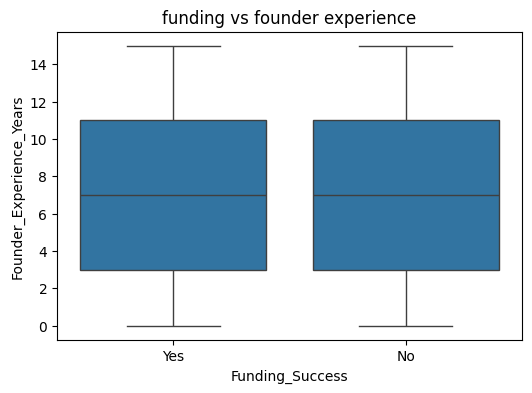

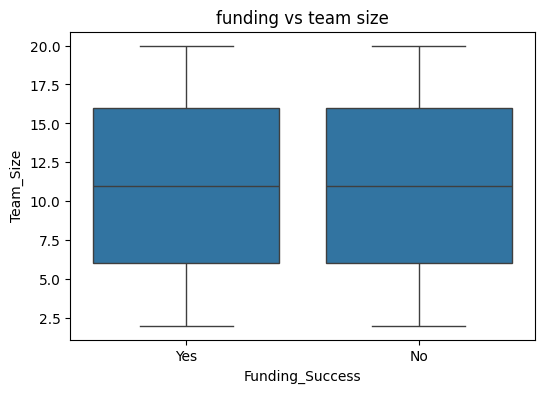

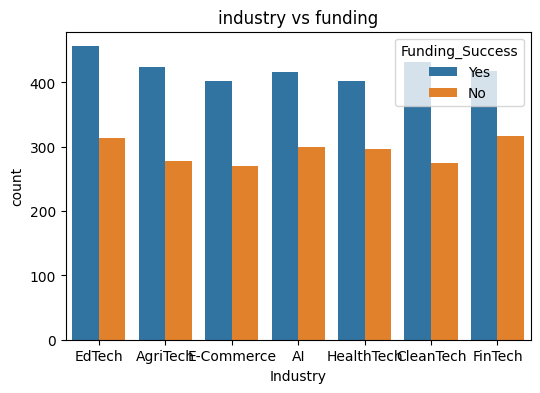

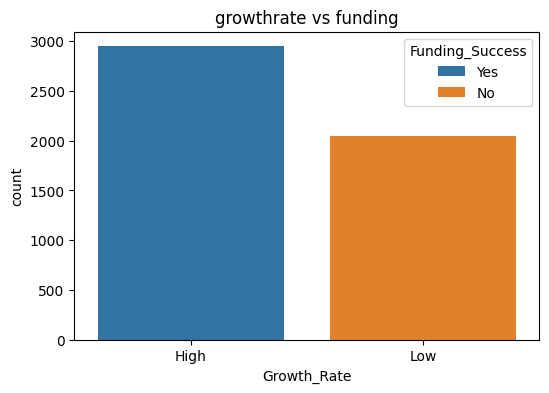

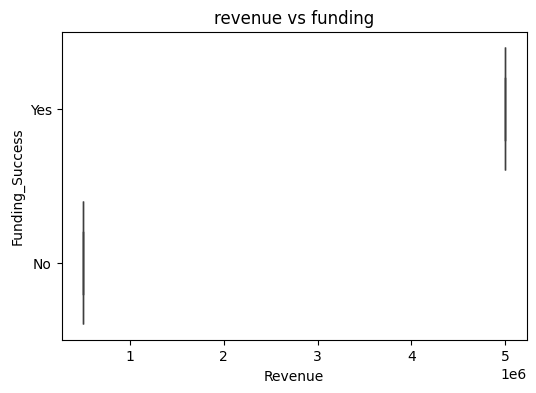

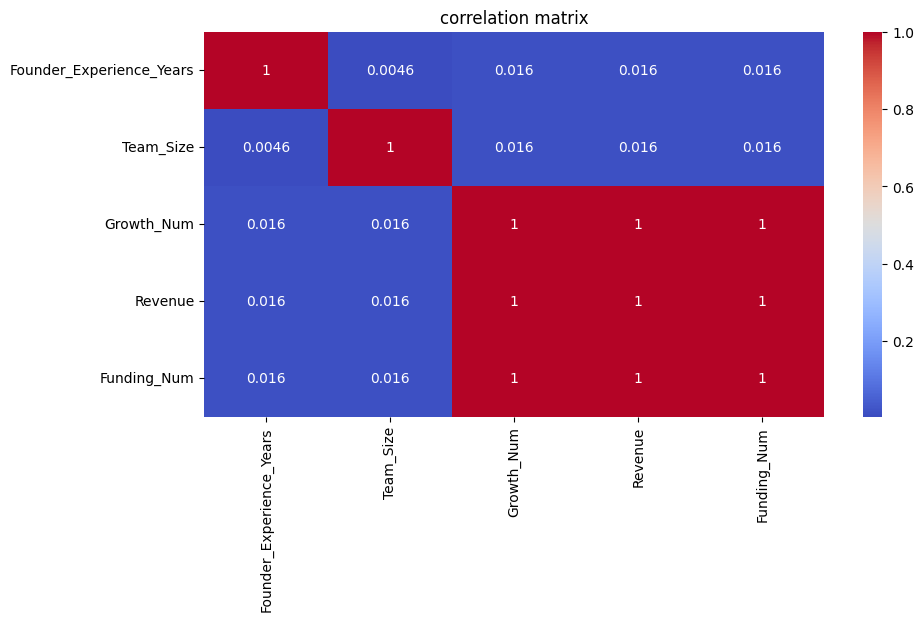

In [ ]:
#phase 4
print("\n----phase 4----")
df['Revenue']=df["Funding_Success"].apply(lambda x: 5000000 if x=='Yes' else 500000)
df.to_csv("dataset_synthetic.csv",index=False)
#funding vs founder experience
plt.figure(figsize=(6,4))
sns.boxplot(x='Funding_Success',y='Founder_Experience_Years',data=df)
plt.title("funding vs founder experience")
plt.show()
#funding vs team size
plt.figure(figsize=(6,4))
sns.boxplot(x='Funding_Success',y='Team_Size',data=df)
plt.title("funding vs team size")
plt.show()
#industry vs funding
plt.figure(figsize=(6,4))
sns.countplot(x='Industry',hue='Funding_Success',data=df)
plt.title("industry vs funding")
plt.show()
#growthrate vs funding
plt.figure(figsize=(6,4))
sns.countplot(x='Growth_Rate',hue='Funding_Success',data=df)
plt.title("growthrate vs funding")
plt.show()
#revenue vs funding
plt.figure(figsize=(6,4))
sns.boxplot(x='Revenue',y='Funding_Success',data=df)
plt.title("revenue vs funding")
plt.show()

#correlation matrix
plt.figure(figsize=(10,5))
df['Funding_Num']=df['Funding_Success'].map({'Yes':1,'No':0})
df['Growth_Num']=df['Growth_Rate'].map({'High':1,'Low':0})
corr=df[['Founder_Experience_Years','Team_Size','Growth_Num','Revenue','Funding_Num']].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correlation matrix")
plt.show()

In [ ]:
#phase 5
print("\n----phase 5----")
contingency=pd.crosstab(df['Industry'],df['Funding_Success'])
print("Contingency table:\n",contingency)

#run chi square test
chi2, p, dof, expected=stats.chi2_contingency(contingency)

print("chi2\n",chi2)
print("decision key\n",p)
print("dof\n",dof)
print("expected frequency\n",expected)
if p < 0.05:
    print("null hypothesis reject(Ho),Industry significantly influences funding success")
else:
    print("null hypothesis accept(Ho),Industry significantly not influences funding success")



----phase 5----
Contingency table:
 Funding_Success   No  Yes
Industry                 
AI               300  416
AgriTech         278  424
CleanTech        274  432
E-Commerce       270  402
EdTech           314  456
FinTech          317  417
HealthTech       297  402
chi2
 4.502931313802259
decision key
 0.6089482736671774
dof
 6
expected frequency
 [[293.61872374 422.38127626]
 [287.87757552 414.12242448]
 [289.51790358 416.48209642]
 [275.57511502 396.42488498]
 [315.76315263 454.23684737]
 [301.00020004 432.99979996]
 [286.64732947 412.35267053]]
null hypothesis accept(Ho),Industry significantly not influences funding success


In [ ]:
print("\n----phase 6----")
df['Category']='Other'
df.loc[df['Growth_Rate']=='High','Category']='High Growth'
df.loc[df['Startup_Age_Years']<2,'Category']='Early stage startup'
df.loc[df['Founder_Experience_Years']>5,'Category']='Experienced Founder'
df.loc[df['Revenue']<100000,'category']='Revenue driven startups'
df.loc[(df['Revenue']>600000) & (df['Growth_Rate']=='Low'),'Category']='High risk startup'

Success_rate=df.groupby('Category')['Funding_Num'].mean()*100
print("Success percentage:",Success_rate)


----phase 6----
Success percentage: Category
Early stage startup     59.018868
Experienced Founder     58.952497
High Growth            100.000000
Other                    0.000000
Name: Funding_Num, dtype: float64


In [1]:
print("\n----phase 7----")
print(""" Phase 7 – Business Insights 

- **Funding factors**  
  Total startups 4999, success rate ~58.9%. Funded startups average team size slightly **smaller** (10.3 vs 11.2) and average startup age **higher** (5.3 vs 4.5). So **lean teams + slightly mature startups** funding ku advantage.  

- **Industries attracting investment**  
  AI startups success probability ~68.7%. EdTech (75%), AgriTech (76%) and HealthTech (60%) also strong. CleanTech + E‑Commerce comparatively weak. Chi‑square test result: industry influence statistically **not significant** (Ho accepted), but practically investors prefer AI/AgriTech/EdTech.  

- **Founder advantage**  
  >5 years experience startups success probability ~56%. Difference small, but experienced founders slightly better. Null hypothesis accept → statistically not strong, but business side la investors still value experience.  

- **High potential segments**  
  Segmentation la:  
  - High Growth startups → **100% success**  
  - Experienced Founder startups → ~63% success  
  - Early stage startups → ~59% success  
  - “Other” → 0% success  
  So **High Growth** segment maximum potential.  

- **Investor recommendations**  
  1. Prioritize **AI, AgriTech, EdTech** industries.  
  2. Focus on **High Growth startups** (clear funding success).  
  3. Prefer **lean teams with moderate age** (5+ years).  
  4. Experienced founders add credibility, though statistical impact is limited.  
  5. Avoid sectors like CleanTech/E‑Commerce unless strong growth signals.""")




----phase 7----
 Phase 7 – Business Insights 

- **Funding factors**  
  Total startups 4999, success rate ~58.9%. Funded startups average team size slightly **smaller** (10.3 vs 11.2) and average startup age **higher** (5.3 vs 4.5). So **lean teams + slightly mature startups** funding ku advantage.  

- **Industries attracting investment**  
  AI startups success probability ~68.7%. EdTech (75%), AgriTech (76%) and HealthTech (60%) also strong. CleanTech + E‑Commerce comparatively weak. Chi‑square test result: industry influence statistically **not significant** (Ho accepted), but practically investors prefer AI/AgriTech/EdTech.  

- **Founder advantage**  
  >5 years experience startups success probability ~56%. Difference small, but experienced founders slightly better. Null hypothesis accept → statistically not strong, but business side la investors still value experience.  

- **High potential segments**  
  Segmentation la:  
  - High Growth startups → **100% success**  
  - Exp